<a href="https://colab.research.google.com/github/Sibuninja/ML_LAB_ASSIGNMENT/blob/ASSIGNMENT-2/Logistic_Regression_Perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab Experiment 2: Logistic Regression and Perceptron

**Objective:** Implement Logistic Regression and the Perceptron learning algorithm from scratch for binary classification using the Breast Cancer dataset.

In [20]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [21]:
# Load Breast Cancer Dataset

data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset Shape:", X.shape)
print("Target Shape:", y.shape)
print("Classes:", data.target_names)

Dataset Shape: (569, 30)
Target Shape: (569,)
Classes: ['malignant' 'benign']


In [22]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (455, 30)
Testing Data : (114, 30)


In [23]:
# Feature Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


## Part A — Logistic Regression From Scratch

In [24]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

In [25]:
class LogisticRegressionScratch:

    def __init__(self, learning_rate=0.01, epochs=2000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = 0.0

    def fit(self, X, y):
        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for _ in range(self.epochs):
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = sigmoid(linear_model)

            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict_probability(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return sigmoid(linear_model)

    def predict(self, X):
        probabilities = self.predict_probability(X)
        return (probabilities >= 0.5).astype(int)

In [26]:
# Train Logistic Regression

logistic_model = LogisticRegressionScratch(
    learning_rate=0.01,
    epochs=2000
)

logistic_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict(X_test)

print("Logistic Regression training completed.")

Logistic Regression training completed.


## Part B — Perceptron From Scratch

In [27]:
class PerceptronScratch:

    def __init__(self, learning_rate=0.01, epochs=100):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = 0.0

    def fit(self, X, y):
        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0.0

        # Convert labels: 0 -> -1, 1 -> +1
        y_perceptron = np.where(y == 0, -1, 1)

        for _ in range(self.epochs):
            for idx, x_i in enumerate(X):
                linear_output = np.dot(x_i, self.weights) + self.bias
                prediction = 1 if linear_output >= 0 else -1

                if prediction != y_perceptron[idx]:
                    self.weights += (
                        self.learning_rate *
                        y_perceptron[idx] *
                        x_i
                    )
                    self.bias += (
                        self.learning_rate *
                        y_perceptron[idx]
                    )

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        predictions = np.where(linear_output >= 0, 1, -1)

        # Convert -1 -> 0
        return np.where(predictions == -1, 0, 1)

In [28]:
# Train Perceptron

perceptron_model = PerceptronScratch(
    learning_rate=0.01,
    epochs=100
)

perceptron_model.fit(X_train, y_train)

y_pred_perceptron = perceptron_model.predict(X_test)

print("Perceptron training completed.")

Perceptron training completed.


## Part C — Evaluation

In [29]:
def evaluate_model(name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n{name}")
    print("-" * 40)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")

    return accuracy, precision, recall, f1

In [30]:
# Evaluate both models

logistic_results = evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_logistic
)

perceptron_results = evaluate_model(
    "Perceptron",
    y_test,
    y_pred_perceptron
)


Logistic Regression
----------------------------------------
Accuracy : 0.9737
Precision: 0.9859
Recall   : 0.9722
F1-Score : 0.9790

Perceptron
----------------------------------------
Accuracy : 0.9474
Precision: 0.9583
Recall   : 0.9583
F1-Score : 0.9583


In [31]:
# Performance Comparison

print("=" * 65)
print("PERFORMANCE COMPARISON")
print("=" * 65)

print(f"{'Metric':<15}{'Logistic Regression':<25}{'Perceptron':<15}")
print("-" * 65)

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

for i, metric in enumerate(metrics):
    print(
        f"{metric:<15}"
        f"{logistic_results[i]:<25.4f}"
        f"{perceptron_results[i]:<15.4f}"
    )

PERFORMANCE COMPARISON
Metric         Logistic Regression      Perceptron     
-----------------------------------------------------------------
Accuracy       0.9737                   0.9474         
Precision      0.9859                   0.9583         
Recall         0.9722                   0.9583         
F1-Score       0.9790                   0.9583         


## Part D — Decision Boundary Using 2 Features

In [32]:
# Select first two features

X_2 = data.data[:, :2]
y_2 = data.target

print("Selected Features:")
print("1.", data.feature_names[0])
print("2.", data.feature_names[1])

Selected Features:
1. mean radius
2. mean texture


In [33]:
# Split and scale 2-feature data

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_2,
    y_2,
    test_size=0.20,
    random_state=42,
    stratify=y_2
)

scaler_2 = StandardScaler()

X2_train = scaler_2.fit_transform(X2_train)
X2_test = scaler_2.transform(X2_test)

In [34]:
# Train both models on two features

logistic_2 = LogisticRegressionScratch(
    learning_rate=0.01,
    epochs=2000
)
logistic_2.fit(X2_train, y2_train)

perceptron_2 = PerceptronScratch(
    learning_rate=0.01,
    epochs=100
)
perceptron_2.fit(X2_train, y2_train)

print("Both models trained on 2 features.")

Both models trained on 2 features.


In [35]:
def plot_decision_boundary(model, X, y, title, feature_names):

    x_min = X[:, 0].min() - 1
    x_max = X[:, 0].max() + 1
    y_min = X[:, 1].min() - 1
    y_max = X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))

    plt.contourf(
        xx,
        yy,
        Z,
        alpha=0.3
    )

    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        edgecolors="black",
        s=40
    )

    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title(title)
    plt.tight_layout()
    plt.show()

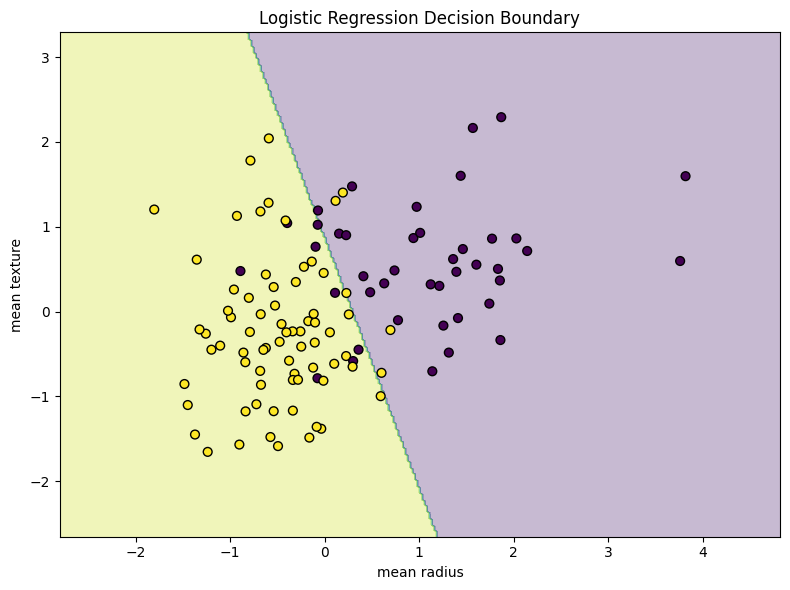

In [36]:
# Logistic Regression Decision Boundary

plot_decision_boundary(
    logistic_2,
    X2_test,
    y2_test,
    "Logistic Regression Decision Boundary",
    data.feature_names[:2]
)

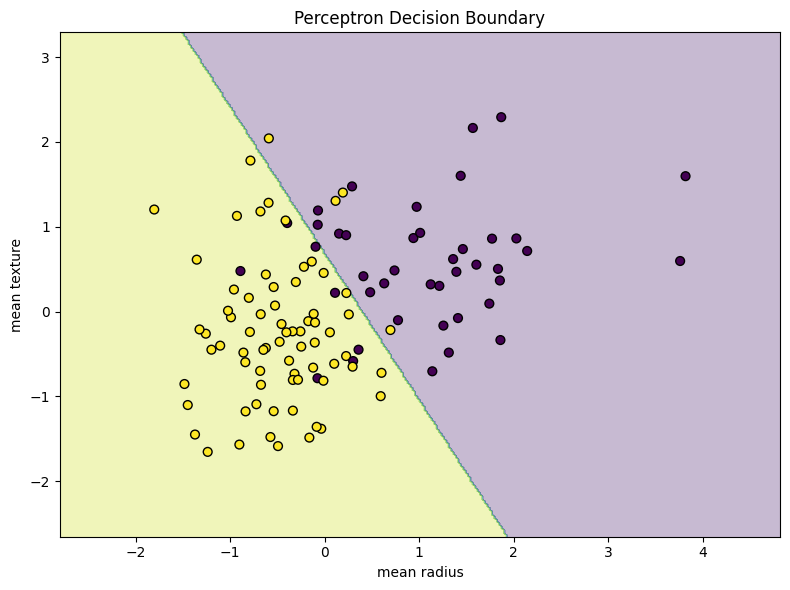

In [37]:
# Perceptron Decision Boundary

plot_decision_boundary(
    perceptron_2,
    X2_test,
    y2_test,
    "Perceptron Decision Boundary",
    data.feature_names[:2]
)

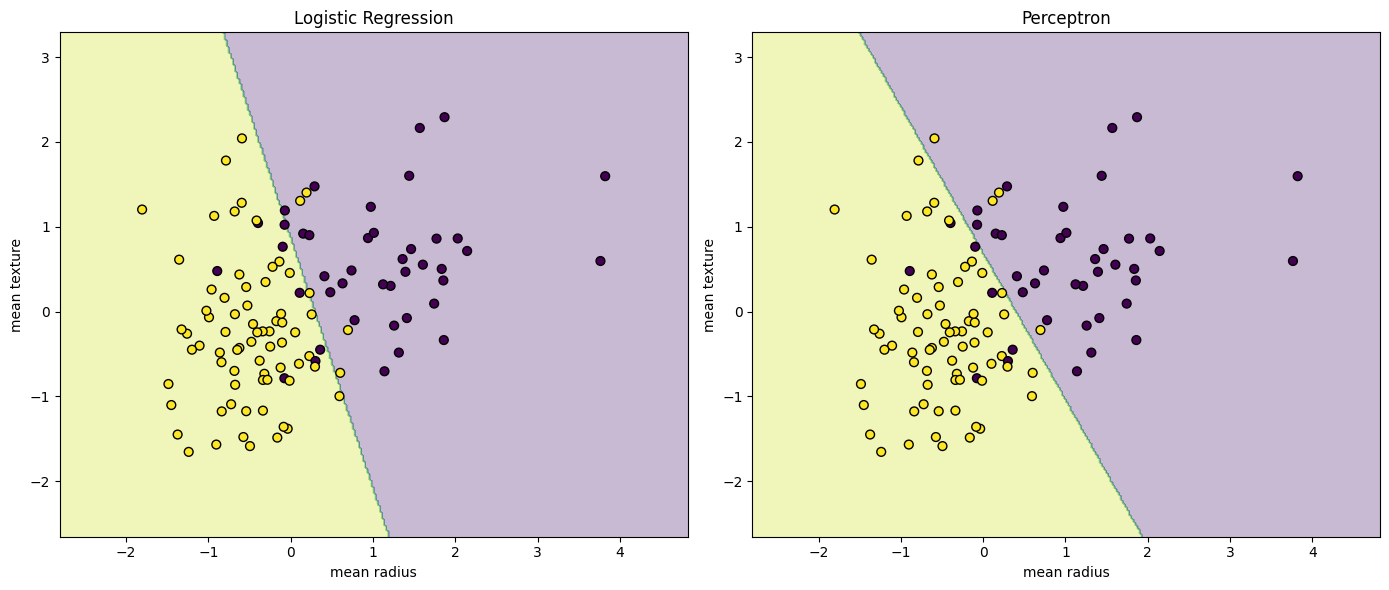

In [38]:
# Combined Decision Boundary Comparison

x_min = X2_test[:, 0].min() - 1
x_max = X2_test[:, 0].max() + 1
y_min = X2_test[:, 1].min() - 1
y_max = X2_test[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]

Z_logistic = logistic_2.predict(grid).reshape(xx.shape)
Z_perceptron = perceptron_2.predict(grid).reshape(xx.shape)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.contourf(xx, yy, Z_logistic, alpha=0.3)
plt.scatter(
    X2_test[:, 0],
    X2_test[:, 1],
    c=y2_test,
    edgecolors="black",
    s=40
)
plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])
plt.title("Logistic Regression")

plt.subplot(1, 2, 2)
plt.contourf(xx, yy, Z_perceptron, alpha=0.3)
plt.scatter(
    X2_test[:, 0],
    X2_test[:, 1],
    c=y2_test,
    edgecolors="black",
    s=40
)
plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])
plt.title("Perceptron")

plt.tight_layout()
plt.show()

## Conclusion

Logistic Regression and Perceptron were implemented from scratch for binary classification using the Breast Cancer dataset. Both models were evaluated using Accuracy, Precision, Recall, and F1-Score. Decision boundaries were also visualized using two selected features.